# Analyse Training Run

This notebook evaluates a completed model training run. It extracts the best epoch statistics, plots the learning curves (Loss, Accuracy, F1), and runs inference on the validation set to generate a Confusion Matrix.

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import pyplot as plt
from src.train.load_run import load_history, load_run_config, resolve_run_and_checkpoint
from src.train.load_run import resolve_run_and_checkpoint, load_history, load_run_config
from src.data_loader import FeatureFusionDataset
from src.models.builder import build_model
from src.notebooks.notebook_utils import resolve_feature_manifests_for_run
from src.preprocessing.feature_modes import feature_mode_to_in_channels

# RUN_INPUT = "../models/saved_weights/irmas_models/irmas_single_label_mel_cnn"
# RUN_INPUT = "../models/saved_weights/irmas_models/irmas_single_label_mel_densenet"
RUN_INPUT = "../models/saved_weights/film_single_label_mel_cnn_ft_irmas"

PREFERRED_WEIGHT = "best_val.pt"

### 1. Training Statistics & Learning Curves

--- Best Validation Performance ---
epoch           30.000000
val_loss         0.002834
val_acc          0.903294
val_macro_f1     0.885583


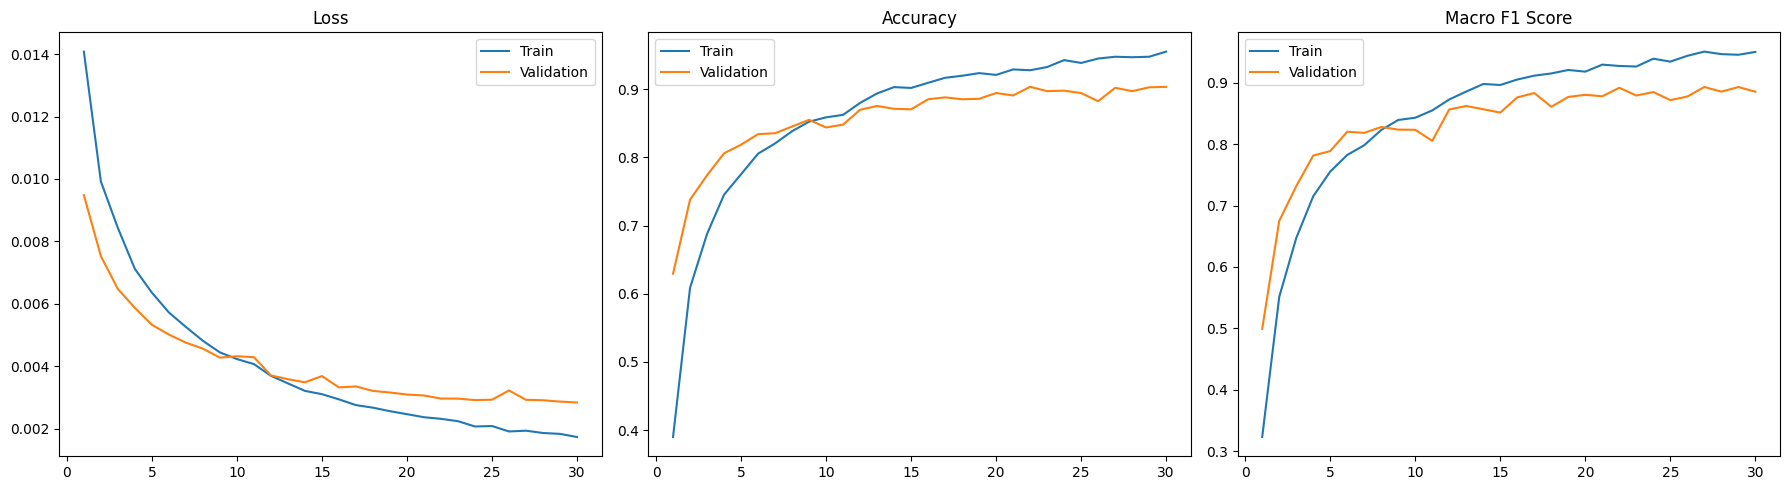

In [5]:


resolved = resolve_run_and_checkpoint(RUN_INPUT, PREFERRED_WEIGHT)
run_cfg = load_run_config(resolved["run_cfg_path"])
history_df, _, _ = load_history(resolved["history_csv_path"], resolved["ckpt_path"])

if not history_df.empty:
    best_epoch = history_df["val_loss"].idxmin()
    best_stats = history_df.iloc[best_epoch][["epoch", "val_loss", "val_acc", "val_macro_f1"]]
    print("--- Best Validation Performance ---")
    print(best_stats.to_string())
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Validation')
    axes[0].set_title('Loss')
    axes[0].legend()
    
    if 'train_acc' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train')
        axes[1].plot(history_df['epoch'], history_df['val_acc'], label='Validation')
        axes[1].set_title('Accuracy')
        axes[1].legend()
        
    if 'train_macro_f1' in history_df.columns:
        axes[2].plot(history_df['epoch'], history_df['train_macro_f1'], label='Train')
        axes[2].plot(history_df['epoch'], history_df['val_macro_f1'], label='Validation')
        axes[2].set_title('Macro F1 Score')
        axes[2].legend()
        
    plt.tight_layout()
    plt.show()

### 2. Validation Inference & Confusion Matrix

Loading model and running inference on validation set...


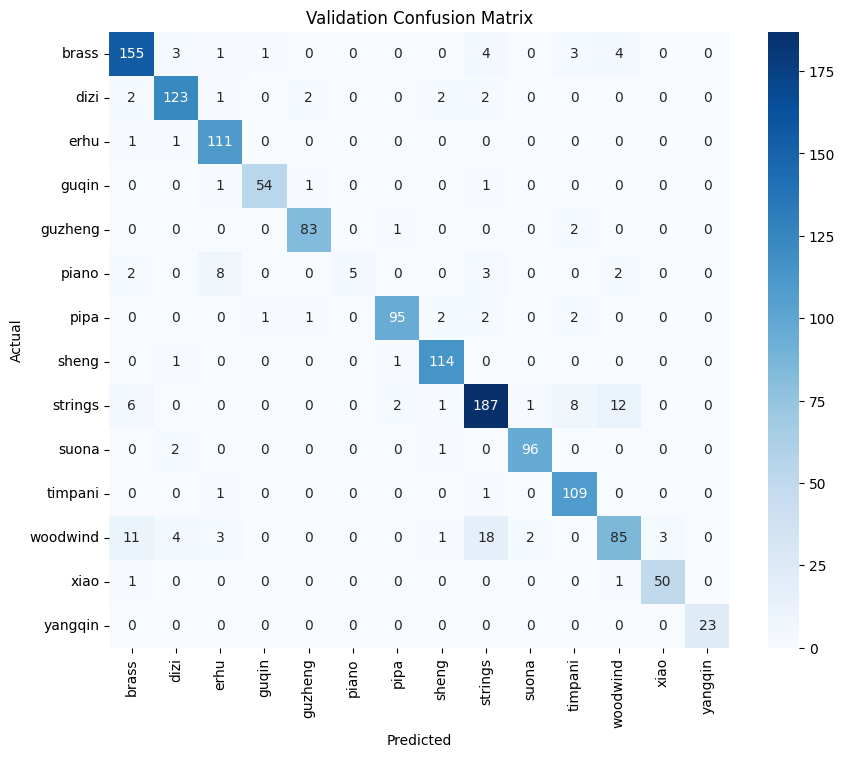


Classification Report:

              precision    recall  f1-score   support

       brass       0.87      0.91      0.89       171
        dizi       0.92      0.93      0.92       132
        erhu       0.88      0.98      0.93       113
       guqin       0.96      0.95      0.96        57
     guzheng       0.95      0.97      0.96        86
       piano       1.00      0.25      0.40        20
        pipa       0.96      0.92      0.94       103
       sheng       0.94      0.98      0.96       116
     strings       0.86      0.86      0.86       217
       suona       0.97      0.97      0.97        99
     timpani       0.88      0.98      0.93       111
    woodwind       0.82      0.67      0.74       127
        xiao       0.94      0.96      0.95        52
     yangqin       1.00      1.00      1.00        23

    accuracy                           0.90      1427
   macro avg       0.93      0.88      0.89      1427
weighted avg       0.90      0.90      0.90      1427



In [6]:
print("Loading model and running inference on validation set...")
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

classes = run_cfg.get("classes", [])
feature_mode = run_cfg.get("feature_mode", "mel")
task_mode = run_cfg.get("task_mode", "single_label")

# 1. Setup Dataset from Saved Split
split_data = torch.load(resolved["split_path"], map_location="cpu", weights_only=False)
val_indices = split_data["val_indices"]

manifest_path, feature_manifest_paths = resolve_feature_manifests_for_run(run_cfg, resolved["project_root"])
dataset = FeatureFusionDataset(
    feature_mode=feature_mode,
    manifest_path=manifest_path,
    class_names=classes,
    feature_manifest_paths=feature_manifest_paths or None,
    project_root=str(resolved["project_root"])
)
val_ds = Subset(dataset, val_indices)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 2. Load Model Weights
in_ch = feature_mode_to_in_channels(feature_mode)
model = build_model(run_cfg["model"]["backbone"], in_ch, len(classes), run_cfg["model"])
ckpt = torch.load(resolved["ckpt_path"], map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

# 3. Run Inference
all_preds, all_targets = [], []

with torch.no_grad():
    for x, y_raw in val_loader:
        x = x.to(device)
        logits = model(x)
        
        if task_mode == "single_label":
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = (torch.argmax(y_raw, dim=1) if y_raw.ndim > 1 else y_raw).cpu().numpy()
        else:
            preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            targets = y_raw.cpu().numpy()
            
        all_preds.extend(preds)
        all_targets.extend(targets)

# 4. Plot Results
if task_mode == "single_label":
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Validation Confusion Matrix')
    plt.show()
    
    print("\nClassification Report:\n")
    print(classification_report(all_targets, all_preds, target_names=classes))
else:
    print("\nMulti-Label Classification Report:\n")
    print(classification_report(all_targets, all_preds, target_names=classes, zero_division=0))